### Search engine with Tools and Agents


In [1]:
## Tools and wrappers
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper


In [ ]:
# api->query run
api_wrapper_key_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=256)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_key_wiki)
wiki.name

'wikipedia'

In [4]:
api_wrapper_key_arxiv=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=250)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_key_arxiv)
arxiv.name

'arxiv'

In [5]:
tools=[arxiv,wiki]

In [7]:
#RAG elements
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['HF_TOKEN']=os.getenv('HF_TOKEN')


In [11]:
loader=WebBaseLoader("https://docs.smith.langchain.com/")
docs=loader.load()
documents=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200).split_documents(docs)
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectordb=FAISS.from_documents(documents,embeddings)
retriever=vectordb.as_retriever()
retriever


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2201.93it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7f2cd224c9d0>, search_kwargs={})

In [38]:
from langchain_classic.tools.retriever import create_retriever_tool
retriever_tool=create_retriever_tool(retriever,"langsmithsearch","The tool is used to search about Langsmith")
retriever_tool

StructuredTool(name='langsmithsearch', description='The tool is used to search about Langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x7f2c8a8cd240>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x7f2c8a8cd3f0>)

In [39]:
tools=[arxiv,wiki,retriever_tool]
print(tools)

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)), WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/hp/Documents/GenAI/LangChain/lib/python3.10/site-packages/wikipedia/__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=256)), StructuredTool(name='langsmithsearch', description='The tool is used to search about Langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x7f2c8a8cd240>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x7f2c8a8cd3f0>)]


In [68]:
#Lets combine tools and LLM Models
from langchain_groq import ChatGroq
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
llm=ChatGroq(model_name="llama-3.3-70b-versatile",temperature=0)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f2c89437d90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f2c88d8a530>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

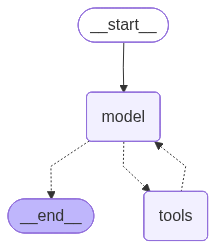

In [73]:
#Agents, new one no need to prompts .The agent use langgraph and they have already knowledge about input and using scrathpad
from langchain.agents import create_agent
#llm=llm.bind_tools(tools)
agent=create_agent(llm,tools,system_prompt="You are an helpful assistant,Use the wikipedia tool to look up information when needed")
agent

In [74]:
response=agent.invoke({"messages":
              [("user","Tell me about LangSmith")]})

In [75]:
response['messages'][-1].content

'LangSmith is a framework-agnostic platform for building, debugging, and deploying AI agents and LLM applications. It provides tools for observability, evaluation, deployment, and platform setup, and meets high standards of data security and privacy with HIPAA, SOC 2 Type 2, and GDPR compliance. LangSmith offers a visual interface for designing and deploying AI agents, as well as a command-line interface for querying and managing traces, datasets, experiments, and more. It also provides a workflow that integrates observability, evaluation, deployment, and platform setup, making it a comprehensive platform for AI application development.'

In [76]:
response2=agent.invoke({'messages':[("user","Tell me about Machine learning")]})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=wikipedia{"query": "Machine learning"}</function>'}}

In [82]:
## Prompt Template
import langchainhub as hub
from langsmith import Client
client=Client()
prompt=client.pull_prompt("hwchase17/openai-functions-agent")
prompt.messages


[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

/tmp/ipykernel_10987/906150838.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent=create_react_agent(llm,tools)


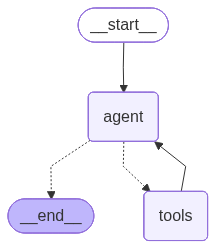

In [85]:
from langgraph.prebuilt import create_react_agent
agent=create_react_agent(llm,tools)
agent

In [86]:
response2=agent.invoke({'messages':[("user","Tell me about Machine learning")]})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=wikipedia{"query": "Machine learning"}</function>'}}